## Pre-amble

# Let's make PSF so we can try something in 3D

(199, 45, 45)


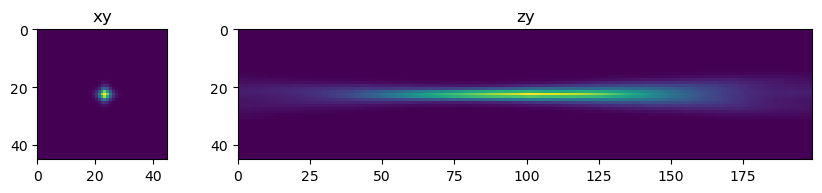

In [76]:
from skimage.io import imread
psf_name = r'/home/bnorthan/images/tnia-python-images/imagesc/2026_03_31_3d_from_2d/astigmatic_psf_beads.tif'
psf = imread(psf_name)
psf = psf[:,:,:]
psf = psf.astype(float)/psf.sum()
print(psf.shape)
from tnia.plotting.projections import show_xy_zy_slice_center

fig = show_xy_zy_slice_center(psf)




## Points


Points at y=50, stepping z and x by 8


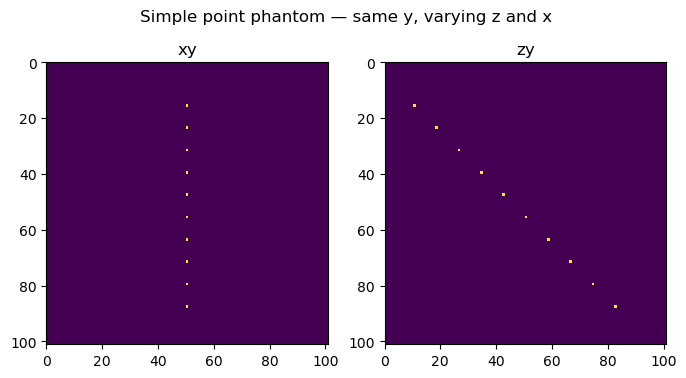

In [77]:
from tnia.plotting.projections import show_xy_zy_max
import numpy as np
import matplotlib.pyplot as plt

z_dim = 101
y_dim = 101
x_dim = 101

phantom = np.zeros((z_dim, y_dim, x_dim), dtype=np.float32)

intensity = 20000

rng = np.random.default_rng(42)

# Place points along a diagonal: same y, stepping through z and x together
xc = x_dim // 2
zstep = 8
ystep = 8
ypos = []
for i, z in enumerate(range(z_dim//2 - zstep*5, z_dim//2 + zstep*5, zstep)):
    y = (i * ystep) % (y_dim - 2 * ystep) + z_dim//2 - (ystep-1)*5
    ypos.append(y)
    phantom[z, y, xc] = intensity

print(f'Points at y={xc}, stepping z and x by {zstep}')
fig = show_xy_zy_max(phantom, figsize=(8,4))
fig.suptitle('Simple point phantom — same y, varying z and x')
plt.show()

## Now lets convolve them

10.271517 0.9999995
10.271517 0.9999995


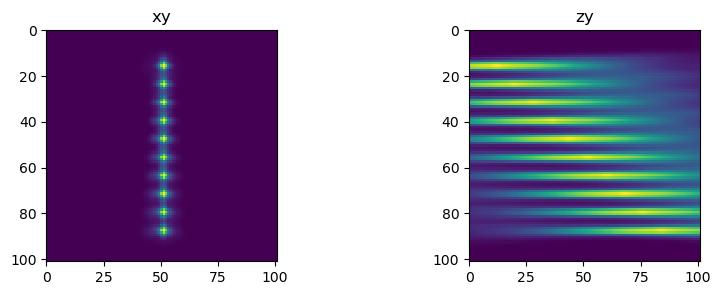

In [131]:
from tnia.deconvolution.forward import forward 

image = forward(phantom, psf, 1, add_poisson=False, gpu=True)
print(image.max(), image.min())
image[image<0]=0
image[image<0]=0
print(image.max(), image.min())

fig = show_xy_zy_max(image)

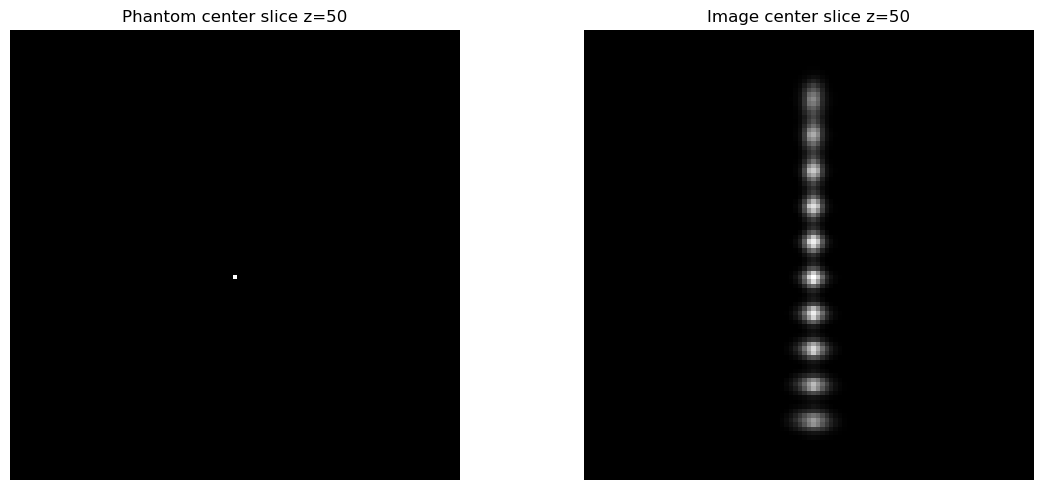

In [132]:
zc = image.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(phantom[zc], cmap='gray', interpolation='nearest')
axes[0].set_title(f'Phantom center slice z={zc}')
axes[0].axis('off')
axes[1].imshow(image[zc], cmap='gray', interpolation='nearest')
axes[1].set_title(f'Image center slice z={zc}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Try 3 decon methods

1.  2D
2.  3D PSF and solution space but 2D input
3.  Full 3D

In [133]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp

iterations = 200

print('--- Running 2D decon ---')
input_slice = image[image.shape[0]//2, :, :]
psf_2d = psf[psf.shape[0]//2] / psf[psf.shape[0]//2].sum()
deconvolved_2d = richardson_lucy_cp(input_slice, psf_2d, iterations)

print()
print('--- Running 2D slice → 3D decon ---')
# add trivial dimension
input_slice = input_slice[np.newaxis, :, :]
deconvolved_2d_3d = richardson_lucy_cp(input_slice, psf, iterations, noncirc=True, do_unpad=True)
deconvolved_2d_3d[deconvolved_2d_3d<0]=0

print()
print('--- Running full 3D decon ---')

deconvolved_3d = richardson_lucy_cp(image, psf, iterations, noncirc=True)

print(deconvolved_3d.min(), deconvolved_3d.max())


--- Running 2D decon ---
Input size: (101, 101), PSF size: (45, 45)
Input is 2D, PSF is 2D

0 20 40 60 80 100 120 140 160 180 

--- Running 2D slice → 3D decon ---
Input size: (1, 101, 101), PSF size: (199, 45, 45)
Input is 2D (single Z plane), PSF is 3D
EXPERIMENTAL: 3D DECON OF 2D SLICE WILL BE DONE

0 20 40 60 80 100 120 140 160 180 

--- Running full 3D decon ---
Input size: (101, 101, 101), PSF size: (199, 45, 45)

0 20 40 60 80 100 120 140 160 180 
0.055757064 417.92703


## Take a look at results

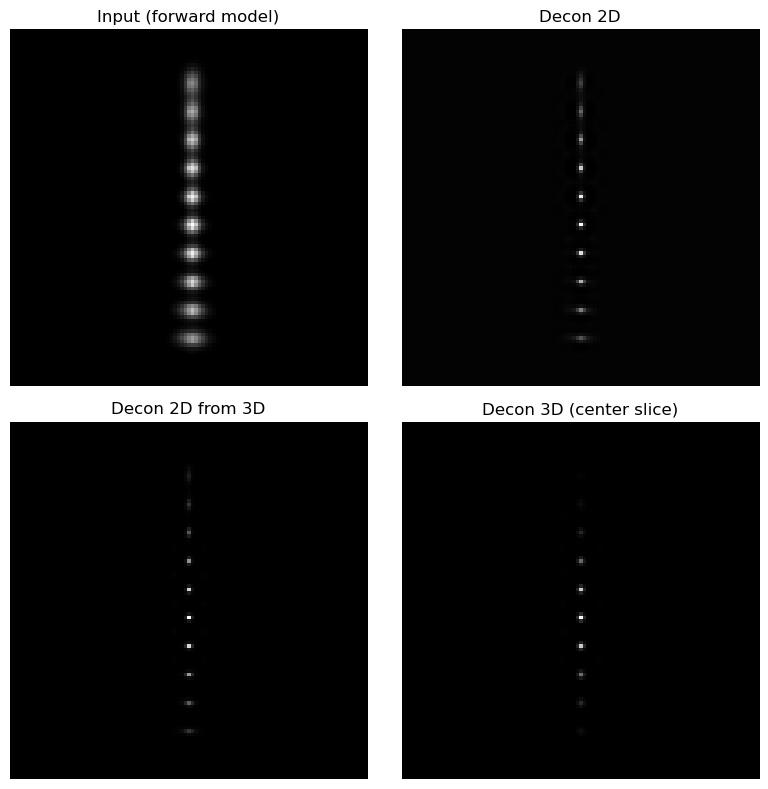

In [135]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(input_slice.squeeze(), cmap='gray')
axes[0, 0].set_title('Input (forward model)')
axes[0, 0].axis('off')
axes[0, 1].imshow(deconvolved_2d.squeeze(), cmap='gray')
axes[0, 1].set_title('Decon 2D')
axes[0, 1].axis('off')
axes[1, 0].imshow(deconvolved_2d_3d.squeeze(), cmap='gray')
axes[1, 0].set_title('Decon 2D from 3D')
axes[1, 0].axis('off')
axes[1, 1].imshow(deconvolved_3d[deconvolved_3d.shape[0]//2], cmap='gray')
axes[1, 1].set_title('Decon 3D (center slice)')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

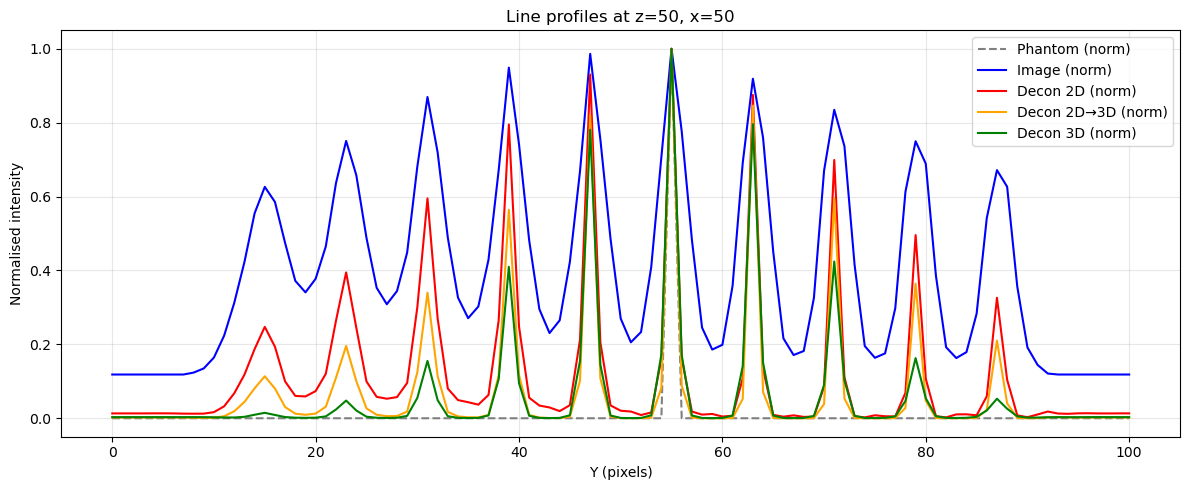

In [136]:
zc = phantom.shape[0] // 2
xc = phantom.shape[2] // 2

profile_phantom    = phantom[zc, :, xc]
profile_image      = image[zc, :, xc]
profile_decon_2d   = deconvolved_2d[:, xc]
profile_decon_2d3d = deconvolved_2d_3d[0, :, xc]
profile_decon_3d   = deconvolved_3d[zc, :, xc]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(profile_phantom    / profile_phantom.max(),    label='Phantom (norm)',     color='gray',   linestyle='--')
ax.plot(profile_image      / profile_image.max(),      label='Image (norm)',       color='blue')
ax.plot(profile_decon_2d   / profile_decon_2d.max(),   label='Decon 2D (norm)',    color='red')
ax.plot(profile_decon_2d3d / profile_decon_2d3d.max(), label='Decon 2D→3D (norm)', color='orange')
ax.plot(profile_decon_3d   / profile_decon_3d.max(),   label='Decon 3D (norm)',    color='green')
ax.set_xlabel('Y (pixels)')
ax.set_ylabel('Normalised intensity')
ax.set_title(f'Line profiles at z={zc}, x={xc}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [137]:

print()
print('--- Running 2D slice → 3D decon ---')
input_slice = image[image.shape[0]//2, :, :]
# add trivial dimension
input_slice = input_slice[np.newaxis, :, :]
deconvolved_2d_3d_full, img_3d_full = richardson_lucy_cp(input_slice, psf, 20000, noncirc=True, do_unpad=False)




--- Running 2D slice → 3D decon ---
Input size: (1, 101, 101), PSF size: (199, 45, 45)
Input is 2D (single Z plane), PSF is 3D
EXPERIMENTAL: 3D DECON OF 2D SLICE WILL BE DONE

0 2000 4000 6000 8000 10000 12000 14000 16000 18000 


In [138]:
# center crop to image size
from tnia.nd.ndutil import centercrop

deconvolved_2d_3d_cropped = centercrop(deconvolved_2d_3d_full, image.shape)
print(f'full shape: {deconvolved_2d_3d_full.shape}, cropped shape: {deconvolved_2d_3d_cropped.shape}')

full shape: (200, 147, 147), cropped shape: (101, 101, 101)


In [142]:
img_cropped.min(), img_cropped.max()

(0.0, 10.096472)

Text(0.5, 0.98, '3D from 2D deconvolution')

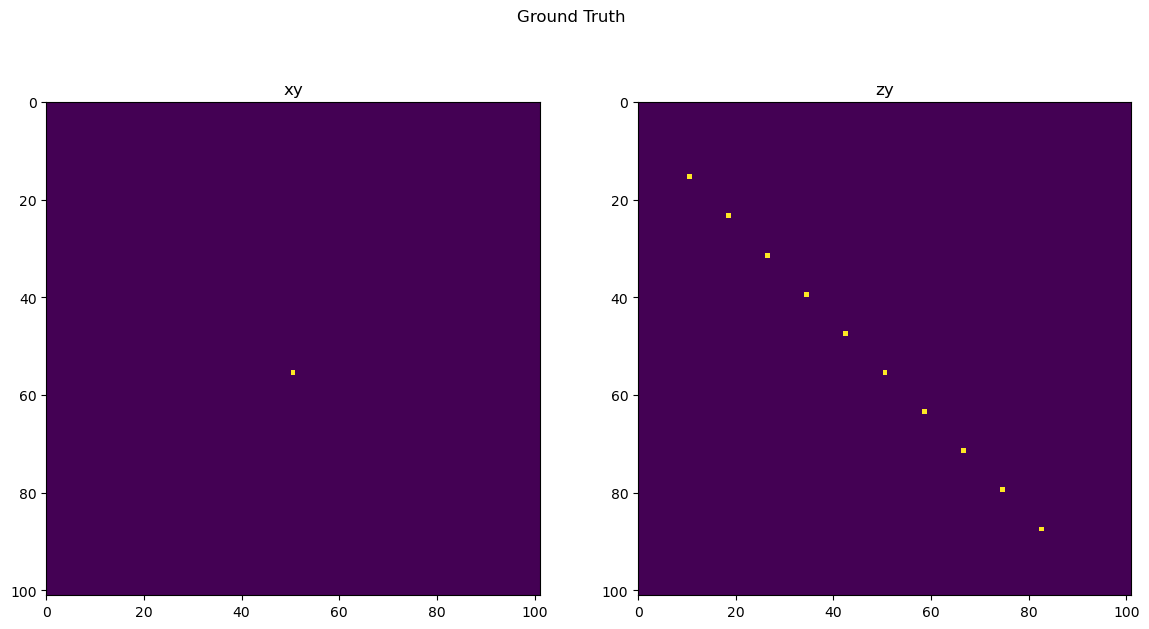

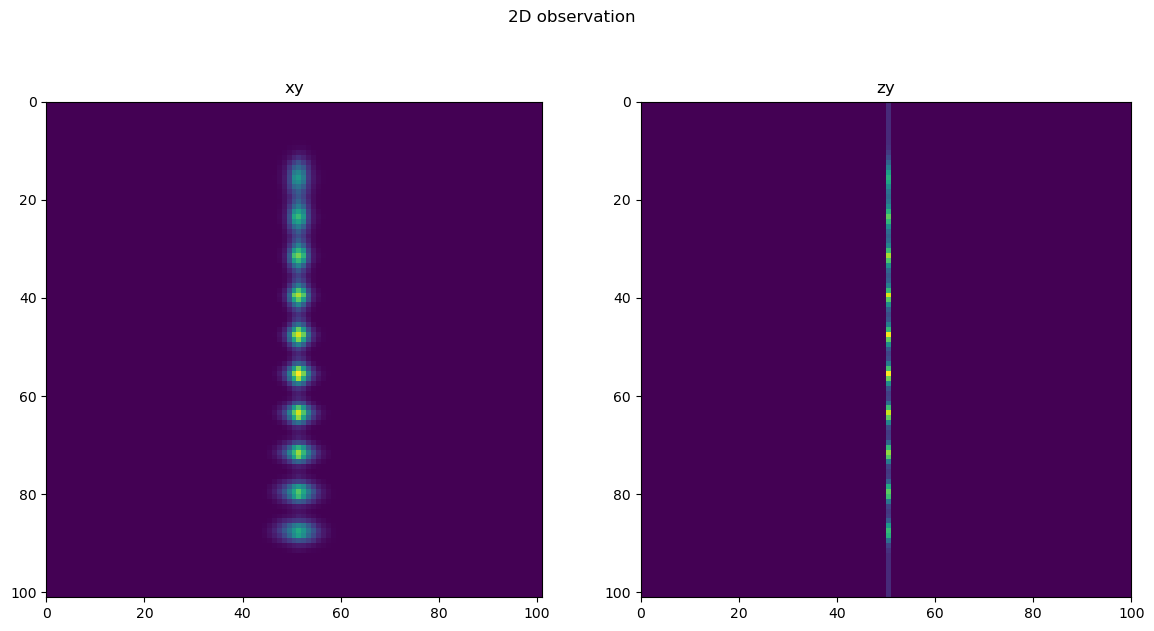

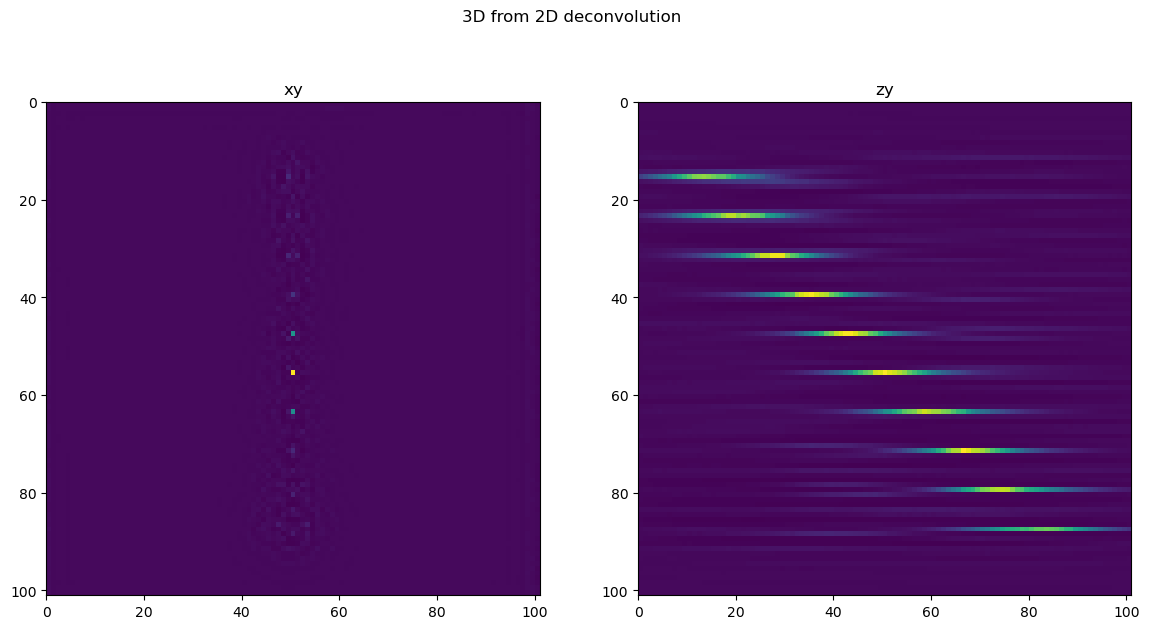

In [145]:
from tnia.nd.ndutil import centercrop
from tnia.plotting.projections import show_xy_zy_slice_center

img_cropped = centercrop(img_3d_full.get(), image.shape)
deconvolved_2d_3d_cropped = centercrop(deconvolved_2d_3d_full, image.shape)

fig = show_xy_zy_slice_center(phantom, figsize=(14,7))
fig.suptitle('Ground Truth')
fig = show_xy_zy_slice_center(img_cropped[1:,:,:], figsize=(14,7))
fig.suptitle('2D observation')
fig = show_xy_zy_slice_center(deconvolved_2d_3d_cropped, gamma = .5, figsize=(14,7))
fig.suptitle('3D from 2D deconvolution')

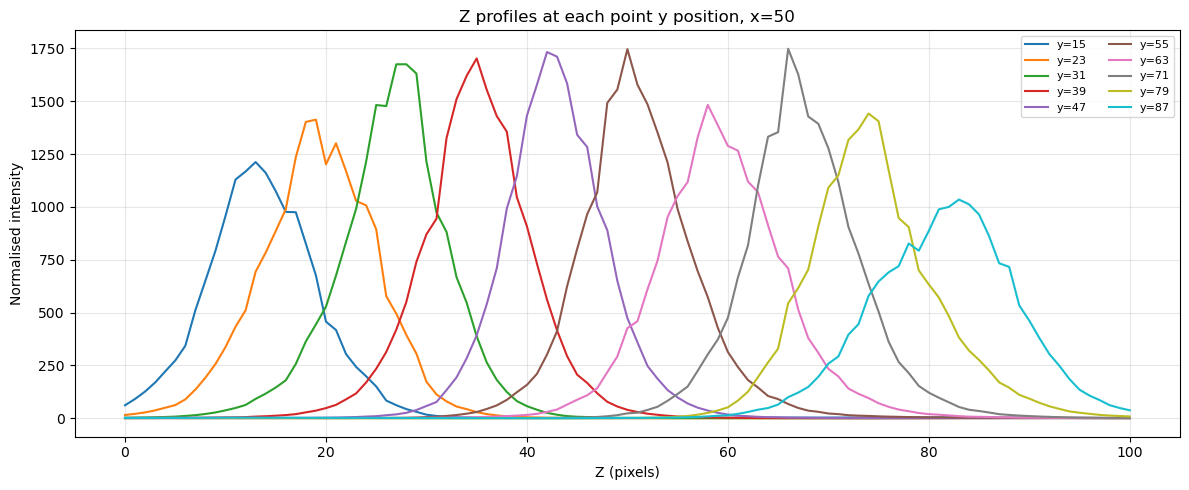

In [146]:
fig, ax = plt.subplots(figsize=(12, 5))

for y in ypos:
    profile = deconvolved_2d_3d_cropped[:, y, xc]
    ax.plot(profile, label=f'y={y}')

ax.set_xlabel('Z (pixels)')
ax.set_ylabel('Normalised intensity')
ax.set_title(f'Z profiles at each point y position, x={xc}')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

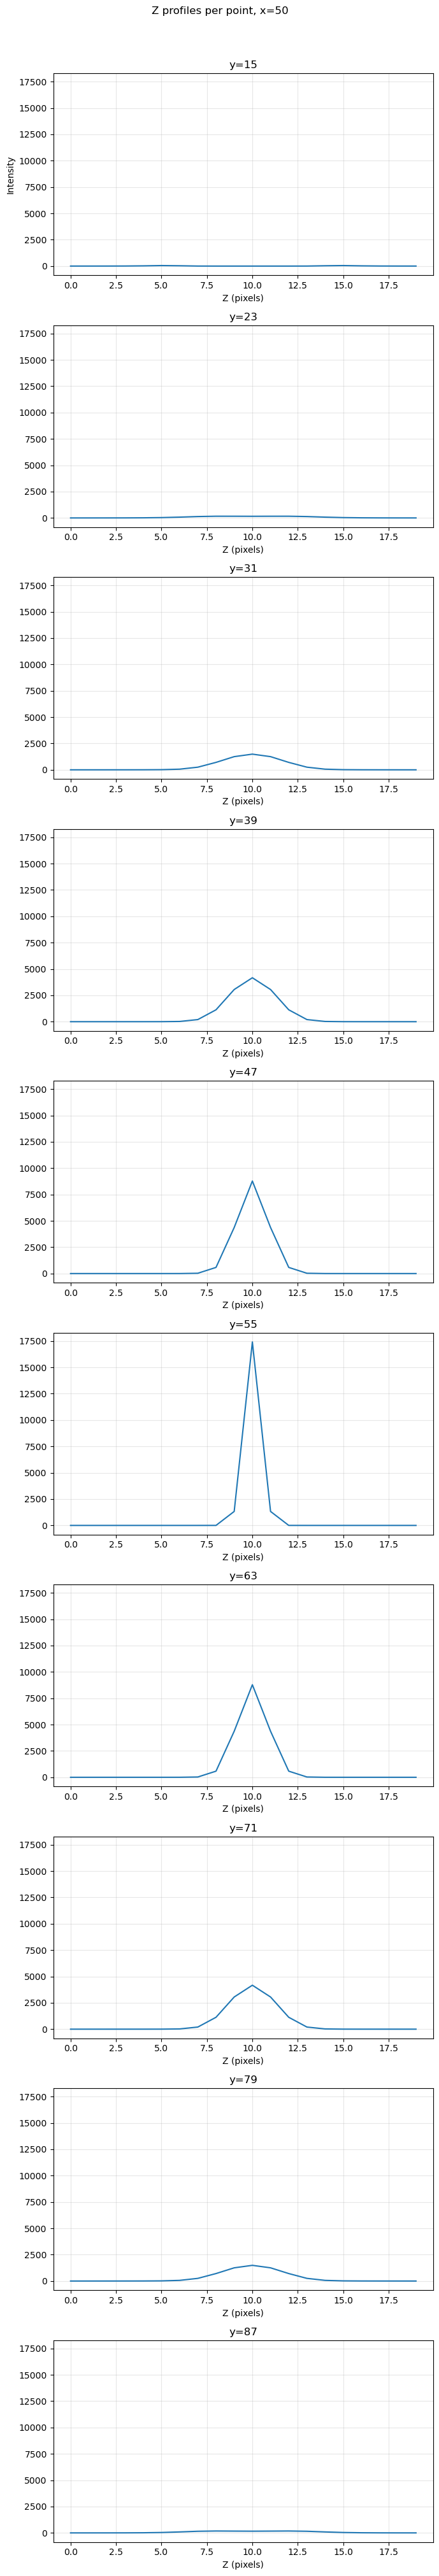

In [86]:
n = len(ypos)
fig, axes = plt.subplots(n, 1, figsize=(7, 4*n), sharey=True)

for ax, y in zip(axes, ypos):
    profile = deconvolved_2d_3d_cropped[40:60, y, xc]
    ax.plot(profile)
    ax.set_title(f'y={y}')
    ax.set_xlabel('Z (pixels)')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Intensity')
plt.suptitle(f'Z profiles per point, x={xc}', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()